In [38]:
from astropy.io import fits
import numpy as np
from astropy.table import Table
import pandas as pd
import glob
from astropy.table import vstack
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages

In [39]:
df_pne = pd.read_csv("../HASH-IPHAS2arcsec-wise3arcsec.csv")
len(df_pne)

313

In [40]:
# YSO

In [113]:
df_yso = pd.read_csv("../YSOs-IPHAS2arcsec-wise3arcsec.csv")
df_yso = df_yso[df_yso["Prob"]>=0.9]
len(df_yso)

144

In [42]:
# 1. Identificar columnas comunes base
common_cols = list(set(df_pne.columns) & set(df_yso.columns))


In [43]:
# 2. Crear nuevas columnas de color en ambos DataFrames
for df in [df_pne, df_yso]:
    # Verificar existencia de columnas necesarias
    if all(col in df.columns for col in ['Jmag', 'Hmag', 'W1mag', 'W2mag']):
        df["J_H"] = df["Jmag"] - df["Hmag"]
        df["H_W2"] = df["Hmag"] - df["W2mag"]
        df["W1_W2"] = df["W1mag"] - df["W2mag"]
        df["J_W2"] = df["Jmag"] - df["W2mag"]
    else:
        missing = [col for col in ['Jmag', 'Hmag', 'W1mag', 'W2mag'] if col not in df.columns]
        raise ValueError(f"Columnas faltantes: {missing}")

In [44]:
# 3. Seleccionar solo las columnas necesarias para los gráficos
selected_cols = ['J_H', 'H_W2', 'W1_W2', 'J_W2']

In [45]:
# Añadir columna de clasificación
df_pne['main_type'] = 'PNe'
df_yso['main_type'] = 'YSOs'


In [46]:
# Combinar solo las columnas seleccionadas
df_combined = pd.concat([
    df_pne[selected_cols + ['main_type']],
    df_yso[selected_cols + ['main_type']]
], ignore_index=True)


In [71]:
# Configuración de estilo
sns.set(style="whitegrid")
palette = sns.color_palette("cubehelix", n_colors=2)


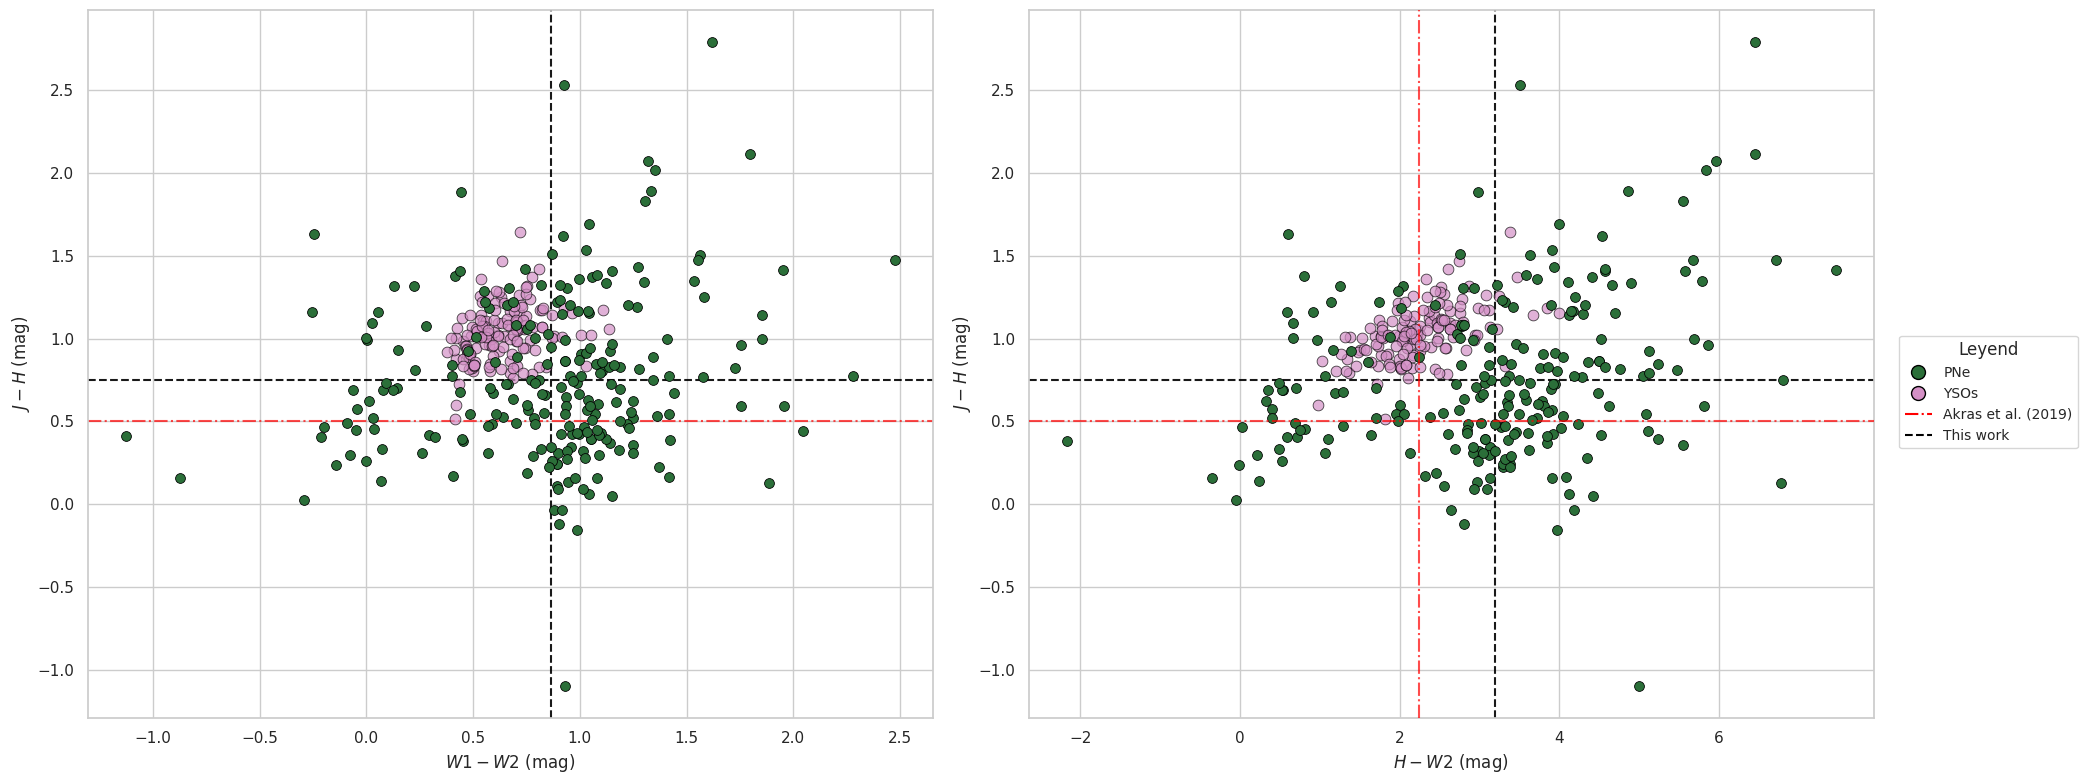

In [115]:
# Crear figura y subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Separar los datos
df_pne = df_combined[df_combined['main_type'] == 'PNe']
df_yso = df_combined[df_combined['main_type'] == 'YSOs']

# Primer gráfico: W1-W2 vs J-H
# Primero YSOs
sns.scatterplot(
    x="W1_W2", y="J_H",
    color=palette[1],  
    data=df_yso, ax=axes[0], s=60, edgecolor='black',
    legend=False, zorder=2, alpha=0.7
)
# Luego PNe
sns.scatterplot(
    x="W1_W2", y="J_H",
    color=palette[0],  
    data=df_pne, ax=axes[0], s=50, edgecolor='black',
    legend=False, zorder=3
)
# Líneas de corte con etiquetas
axes[0].axvline(0.865, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[0].axhline(0.75, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[0].axhline(0.5, color='red', linestyle='-.', alpha=0.7, zorder=1)
axes[0].set_xlabel(r"$W1 - W2$ (mag)")
axes[0].set_ylabel(r"$J - H$ (mag)")

# Segundo gráfico: H-W2 vs J-H
# Primero YSOs
sns.scatterplot(
    x="H_W2", y="J_H",
    color=palette[1],  
    data=df_yso, ax=axes[1], s=60, edgecolor='black',
    legend=False, zorder=2, alpha=0.7
)
# Luego PNe
sns.scatterplot(
    x="H_W2", y="J_H",
    color=palette[0],  
    data=df_pne, ax=axes[1], s=50, edgecolor='black',
    legend=False, zorder=3
)
# Líneas de corte con etiquetas
axes[1].axvline(3.2, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[1].axhline(0.75, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[1].axvline(2.24, color='red', linestyle='-.', alpha=0.7, zorder=4)
axes[1].axhline(0.5, color='red', linestyle='-.', alpha=0.7, zorder=4)
axes[1].set_xlabel(r"$H - W2$ (mag)")
axes[1].set_ylabel(r"$J - H$ (mag)")

# Leyenda unificada con elementos personalizados
legend_elements = [
    # Elementos de dispersión
    Line2D([0], [0], marker='o', color='w', label='PNe', zorder=3,
           markerfacecolor=palette[0], markersize=10, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', label='YSOs', zorder=2,
           markerfacecolor=palette[1], markersize=10, markeredgecolor='black'),
    
    # Elementos de líneas
    Line2D([0], [0], color='red', linestyle='-.', label='Akras et al. (2019)'),
    Line2D([0], [0], color='black', linestyle='--', label='This work')
    
]

# Crear leyenda en dos columnas
fig.legend(handles=legend_elements, title="Leyend",
           bbox_to_anchor=(0.95, 0.5), loc='center left',
           ncol=1, fontsize=10, title_fontsize=12)

# Ajustar layout para espacio de leyenda
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

# PNe candidate-- IGAPs (Group 4)

In [200]:
df_pne_g4 = pd.read_csv("../Resultados_PNE/PNe_candidatos_HW2.csv")
for i in df_pne_g4.columns:
    print(i)

Name
RAJ2000
DEJ2000
GLON
GLAT
SourceID
ePos
Class
pStar
pGalaxy
pNoise
imag
e_imag
imagAB
Elli
Classi
Deblendi
Saturatedi
Vignettedi
Traili
Truncatedi
BadPixi
MJDi
Seeingi
DetIDi
offRAi
offDEi
Hamag
e_Hamag
HamagAB
EllHa
ClassHa
DeblendHa
SaturatedHa
VignettedHa
TrailHa
TruncatedHa
BadPixHa
MJDHa
SeeingHa
DetIDHa
offRAHa
offDEHa
rImag
e_rImag
rImagAB
EllrI
ClassrI
DeblendrI
SaturatedrI
VignettedrI
TrailrI
TruncatedrI
BadPixrI
MJDrI
SeeingrI
DetIDrI
rUmag
e_rUmag
rUmagAB
EllrU
ClassrU
DeblendrU
SaturatedrU
VignettedrU
TrailrU
TruncatedrU
BadPixrU
MJDrU
SeeingrU
DetIDrU
offRArU
offDErU
gmag
e_gmag
gmagAB
Ellg
Classg
Deblendg
Saturatedg
Vignettedg
Trailg
Truncatedg
BadPixg
maskg
MJDg
Seeingg
DetIDg
offRAg
offDEg
Umag
e_Umag
EllU
ClassU
DeblendU
SaturatedU
VignettedU
TrailU
TruncatedU
BadPixU
MJDU
SeeingU
DetIDU
offRAU
offDEU
brightN
deblend
saturated
nBands
errBits
nObsI
nObsU
FieldIDI
FieldIDU
FieldGradeI
FieldGradeU
emitter
variable
SourceID2
imag2
e_imag2
Classi2
Seeingi2
MJDi2
offRAi

In [197]:
# Verificar existencia de columnas necesarias en df_pne_g4
required_columns = ['Jmag', 'Hmag', 'W1mag', 'W2mag']
if all(col in df_pne_g4.columns for col in required_columns):
    df_pne_g4["J_H"] = df_pne_g4["Jmag"] - df_pne_g4["Hmag"]
    df_pne_g4["H_W2"] = df_pne_g4["Hmag"] - df_pne_g4["W2mag"]
    df_pne_g4["W1_W2"] = df_pne_g4["W1mag"] - df_pne_g4["W2mag"]
    df_pne_g4["J_W2"] = df_pne_g4["Jmag"] - df_pne_g4["W2mag"]
else:
    missing = [col for col in required_columns if col not in df_pne_g4.columns]
    raise ValueError(f"Columnas faltantes: {missing}")

In [198]:

sns.set(style="whitegrid")
palette = sns.color_palette("cubehelix")


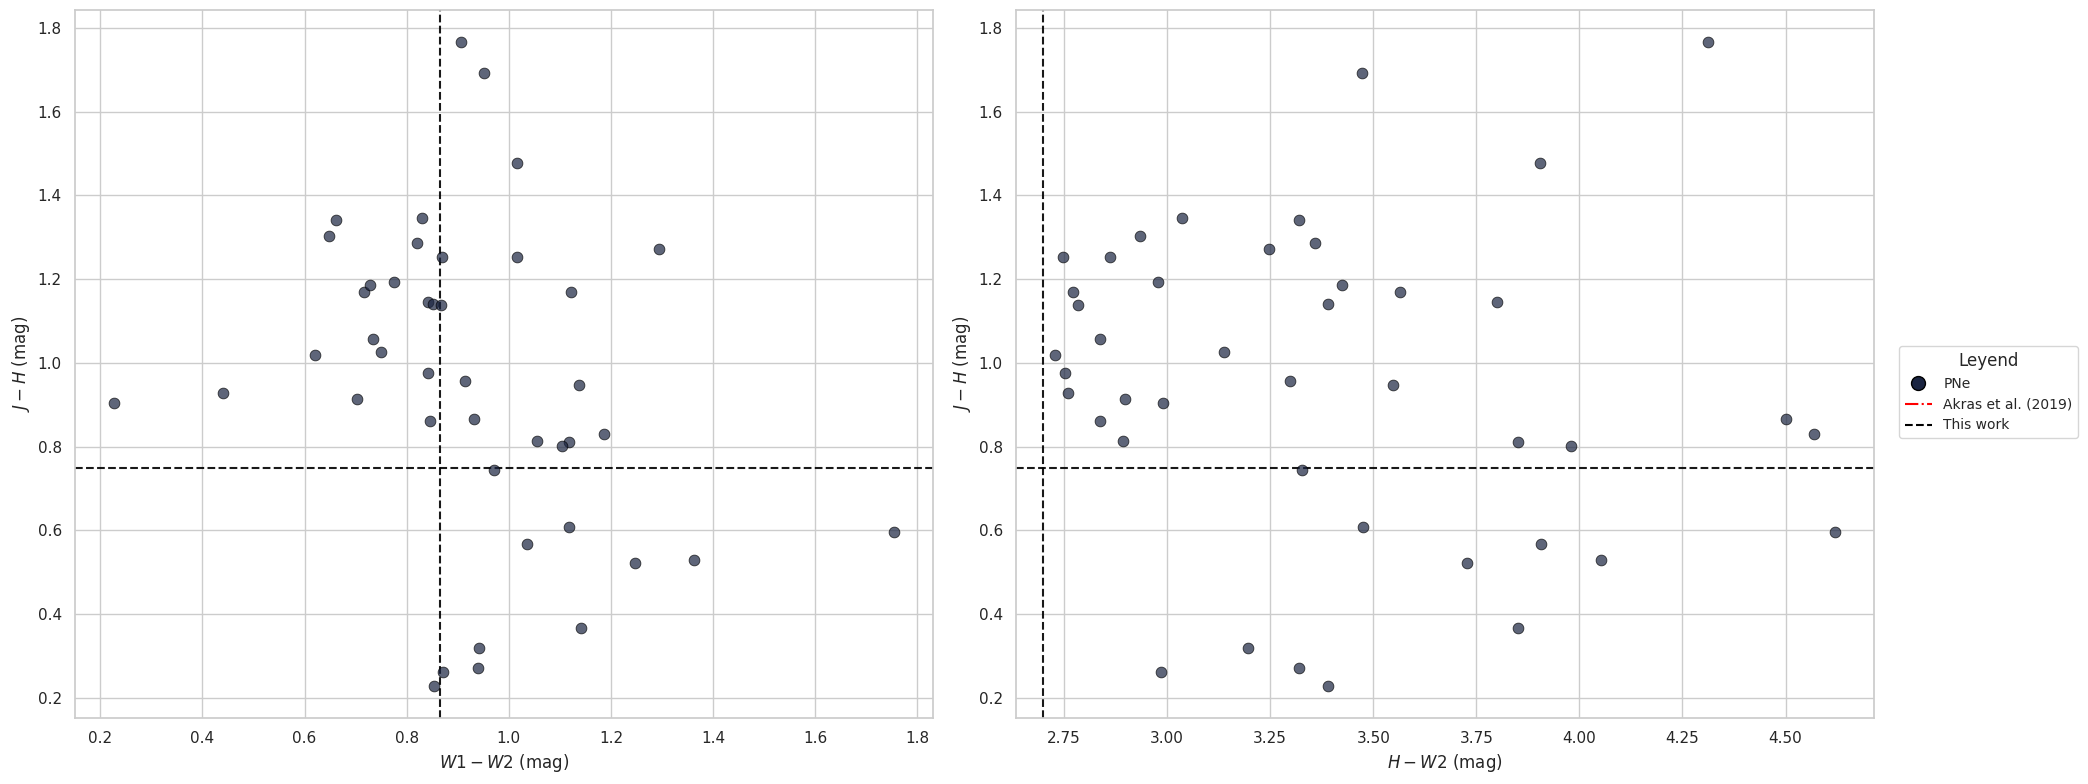

In [199]:
# Crear figura y subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Primer gráfico: W1-W2 vs J-H

# Primer gráfico: W1-W2 vs J-H
sns.scatterplot(
    x="W1_W2", y="J_H",
    color=palette[0],  # Usar el primer color de la paleta para todos los puntos
    data=df_pne_g4, ax=axes[0], s=60, edgecolor='black',
    legend=False, zorder=2, alpha=0.7
)

# Segundo gráfico: H-W2 vs J-H
sns.scatterplot(
    x="H_W2", y="J_H",
    color=palette[0],  # Usar el primer color de la paleta para todos los puntos
    data=df_pne_g4, ax=axes[1], s=60, edgecolor='black',
    legend=False, zorder=2, alpha=0.7
)

# Líneas de corte con etiquetas
axes[0].axvline(0.865, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[0].axhline(0.75, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[0].set_xlabel(r"$W1 - W2$ (mag)")
axes[0].set_ylabel(r"$J - H$ (mag)")



# Líneas de corte con etiquetas
axes[1].axvline(2.7, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[1].axhline(0.75, color='black', linestyle='--', alpha=0.9, zorder=1)
axes[1].set_xlabel(r"$H - W2$ (mag)")
axes[1].set_ylabel(r"$J - H$ (mag)")

# Leyenda unificada con elementos personalizados
legend_elements = [
    # Elementos de dispersión
    Line2D([0], [0], marker='o', color='w', label='PNe', zorder=3,
           markerfacecolor=palette[0], markersize=10, markeredgecolor='black'),
    # Elementos de líneas
    Line2D([0], [0], color='red', linestyle='-.', label='Akras et al. (2019)'),
    Line2D([0], [0], color='black', linestyle='--', label='This work')
    
]

# Crear leyenda en dos columnas
fig.legend(handles=legend_elements, title="Leyend",
           bbox_to_anchor=(0.95, 0.5), loc='center left',
           ncol=1, fontsize=10, title_fontsize=12)

# Ajustar layout para espacio de leyenda
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()